In [7]:
import os
import datetime
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
from scipy import signal, integrate, stats
import yaml
import importlib

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d import Axes3D, axes3d
from matplotlib.colors import LinearSegmentedColormap

from scipy.signal import detrend, find_peaks, savgol_filter
import pywt

import cmaps, plt_helper, filter

plt.style.use('latex_default.mplstyle')

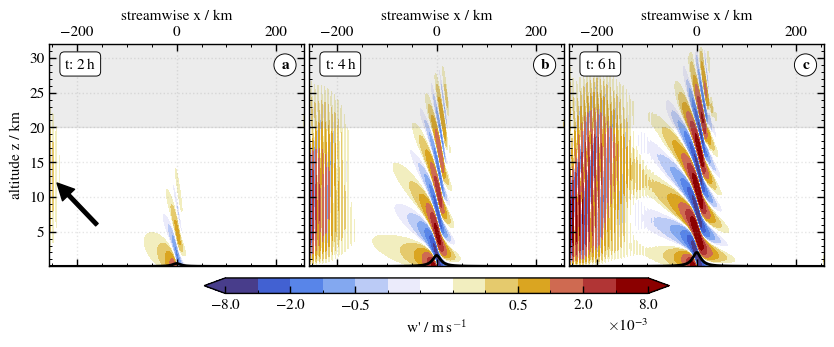

In [8]:
model = "eulag"
folder = "/work/bd0620/b309199/linear-mws"
sim = f"eulag_compressi_MW_010km_relax0"
sim = f"eulag_anelastic_MW_010km_filw"
sim = f"pmap_ppm_MW_010km"
sim = f"eulag_anelastic_MW_010km_inflow"
sim = f"eulag_anelastic_MW_010km_inflow_agnesi"
sims = [sim, sim, sim]

model = sims[0].split("_")[0]
labels = ["t0", "Rigid x-bounds", "t3"]

var0 = "w"
# clev, clev_l = plt_helper.get_colormap_bins_and_labels(max_level=0.8)
clev   = [-4,-2,-1,-0.5,-0.25,-0.125,0.125,0.25,0.5,1,2,4]
clev_l = [-4,-1,-0.25,0.25,1,4]

clev   = [-8,-4,-2,-1,-0.5,-0.25,-0.125,0.125,0.25,0.5,1,2,4,8]
clev_l = [-8,-2,-0.5,0.5,2,8]

clev = np.array(clev) / 1000
clev_l = np.array(clev_l) / 1000
cbar_label0 = r"w' / m$\,$s$^{-1}$"
cmap = cmaps.get_wave_cmap()
norm = BoundaryNorm(boundaries=clev , ncolors=cmap.N, clip=True)

gskw  = {'hspace':0.02, 'wspace':0.02, 'height_ratios': [5,1]} #  , 'width_ratios': [5,5]}
fig, axes = plt.subplots(2,3, figsize=(10,3.5), gridspec_kw=gskw)
axes[-1,0].axis('off')
axes[-1,1].axis('off')
axes[-1,2].axis('off')

z=0
timesteps = [12,24,48]
timesteps = [144,288,432]
for i, sim in enumerate(sims):
    fpath = os.path.join(folder,sim)
    t = timesteps[i]
    if model == "pmap":
        dsxz, dsxy, cfg = plt_helper.preprocess_pmap(fpath, t=t, slices={"x": 0, "y": 0, "z": 0})
        dsxz['xcr']=dsxz.x.expand_dims(ycr=np.shape(dsxy['w'])[0]) / 1000
        dsxz['zcr']=dsxz.zcr / 1000
        dsxy['xcr']=dsxy.x.expand_dims(y=np.shape(dsxy['w'])[0])  / 1000
        dsxy['ycr']=dsxy.y.expand_dims(x=np.shape(dsxy['w'])[1], axis=1)  / 1000
        dsxy['zcr']=dsxy['zcr'] / 1000
    else:
        _, dsxz, _, ds_xyslices = plt_helper.preprocess_eulag_tstep(fpath, t, slices={"x": 0, "y": 0, "z": [0]})
        dsxy = ds_xyslices[0]
        dsxy['zcr']=dsxy['zcrtopo'] / 1000
        cfg = None

    ax0 = axes[0,i]

    var0_filtered = dsxz[var0].values
    # var0_filtered = filter.fil2dx(var0_filtered, ifil=5)
    contf = ax0.contourf(dsxz.xcr[0,:].expand_dims(z=np.shape(dsxz['w'])[0]),
                            dsxz.zcr, var0_filtered, cmap=cmap, norm=norm, levels=clev, extend='both')
    ax0.plot(dsxz.xcr[0,:],200*dsxz.zcr[0,:],lw=2,color='black')
    # ax0.text(0.03, 0.94, 'a', transform=ax0.transAxes, weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

    ax0.xaxis.set_label_position('top')
    ax0.set_xlabel("streamwise x / km")
    ax0.tick_params(which='both',labeltop=True, labelbottom=False, labelleft=False)

    # print(dsxz.time)
    xp = 0.94
    yp = 0.89
    ax0.text(1-xp, yp, f"t: {int(t*50/3600)}$\,$h", transform=ax0.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

    if i == 0:
        ax0.tick_params(which='both', labelleft=True)
        ax0.set_ylabel("altitude z / km")
        
    ## Sponge layer
    alpha_sponge = 0.15
    csponge = "grey"
    
    # xsponge = [(dsxz.x[0] + cfg['absorber']['widthx'])/1000, (dsxz.x[-1] - cfg['absorber']['widthx'])/1000]
    # zsponge = [(dsxz.zcr.max().values - cfg['absorber']['depth']/1000), dsxz.zcr.max().values]
    zsponge = 20
    ax0.axhspan(zsponge, dsxz.zcr.max().values, alpha=alpha_sponge, color=csponge)
    # ax0.fill_between(xsponge, [zsponge[1],zsponge[1]], [zsponge[0],zsponge[0]], facecolor=csponge, alpha=alpha_sponge)
    # ax0.axvspan(dsxz.x[0]/1000, (dsxz.x[0]+cfg['absorber']['widthx'])/1000, alpha=alpha_sponge, color=csponge)
    # ax0.axvspan((dsxz.x[-1] - cfg['absorber']['widthx'])/1000, dsxz.x[-1]/1000, alpha=alpha_sponge, color=csponge)
    
numstr = ['a','b','c','d','e','f']
for i, ax in enumerate(axes.flatten()):
    if i < 3:
        ax.text(xp, yp, numstr[i], transform=ax.transAxes, horizontalalignment='right', weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
        ax.grid()
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())

axes[0,0].annotate('',xy=(-240,12),xytext=(-160,6),arrowprops={'width':2.5, 'fc':'black'})

cbar = fig.colorbar(
    contf, ax=axes[-1,0:3], location='bottom', shrink=0.6, ticks=clev_l, label=cbar_label0, pad=0, extend='both', fraction=0.8, aspect=30)

cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)

fig_title = 'slices_inflowWaves_temp.png'
fig.savefig(os.path.join('../data/pmap', fig_title), facecolor='w', edgecolor='w',
                format='png', dpi=300, bbox_inches='tight')


Ref:
  Peak 1: 38.857 km
  Peak 2: 6.368 km

$1/2\,L$:
  Peak 1: 27.645 km
  Peak 2: 6.787 km

$2\,L$:
  Peak 1: 6.368 km
  Peak 2: 60.748 km

$3/2\,u_e$:
  Peak 1: 47.058 km
  Peak 2: 9.745 km

$2\,u_e$:
  Peak 1: 50.160 km
  Peak 2: 13.127 km

$1/2\,N$:
  Peak 1: 47.058 km
  Peak 2: 13.992 km

$2\,h_0$:
  Peak 1: 38.857 km
  Peak 2: 6.368 km


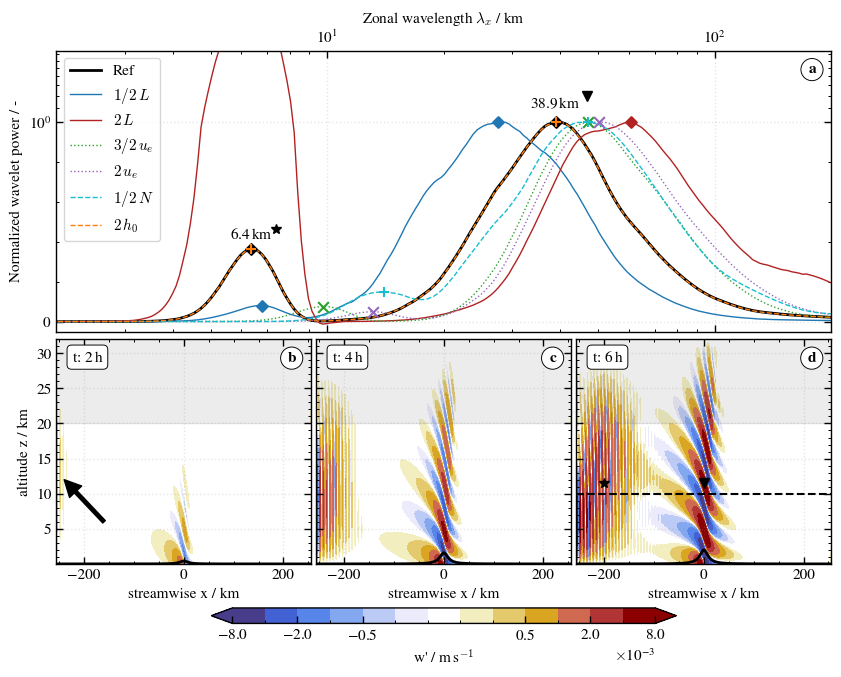

In [10]:
def analyze_multiple_arrays_wavelet(
    arrays,
    axes,
    dx=500.0,
    labels=None,
    colors=None,
    markers=None,
    wavelet="morl",
    wavelength_min_km=1.0,
    wavelength_max_km=200.0,
    n_wavelengths=200,
    detrend_data=True,
    aggregate="percentile",      # "mean", "max", or "percentile"
    aggregate_percentile=90,
    smooth_window=11,
    smooth_polyorder=2,
    min_peak_distance_km=2.0,
    prominence_factor=0.05,
    n_peaks=2,
    xscale="log"
):
    """
    Continuous wavelet analysis for multiple 1D arrays.
    Produces one spectrum-like curve per array: power aggregated over position vs wavelength.

    Parameters
    ----------
    arrays : list of 1D arrays
    dx : float
        Sample spacing in meters.
    labels : list of str
    wavelet : str
        PyWavelets continuous wavelet name, e.g. "morl"
    wavelength_min_km, wavelength_max_km : float
        Wavelength range to analyze.
    n_wavelengths : int
        Number of wavelengths/scales to sample.
    detrend_data : bool
        Remove linear trend before analysis.
    aggregate : str
        How to collapse power across position:
        - "mean"        -> average power over all positions
        - "max"         -> max power over positions
        - "percentile"  -> robust for localized but strong signals
    aggregate_percentile : float
        Used if aggregate == "percentile"
    smooth_window : int
        Smoothing window applied to the final 1D power spectrum
    smooth_polyorder : int
        Savitzky-Golay polynomial order
    min_peak_distance_km : float
        Minimum separation between reported peaks
    prominence_factor : float
        find_peaks prominence as a fraction of max smoothed power
    n_peaks : int
        Number of dominant wavelengths to print
    xscale : str
        "log" or "linear"
    """

    if labels is None:
        labels = [f"array_{i+1}" for i in range(len(arrays))]

    ax0 = axes[0]
    
    # wavelengths we want to analyze
    wavelengths_km = np.geomspace(wavelength_min_km, wavelength_max_km, n_wavelengths)
    wavelengths_m = wavelengths_km * 1000.0

    # convert desired wavelength -> wavelet scale
    # wavelength = sampling_period / frequency
    # with pywt.scale2frequency: frequency = scale2frequency(wavelet, scale) / sampling_period
    # => wavelength = sampling_period / frequency = sampling_period^2 / scale2frequency? easier:
    # scale = scale2frequency(wavelet, 1) / (frequency * sampling_period)
    # since frequency = 1 / wavelength:
    # scale = scale2frequency(wavelet, 1) * wavelength / sampling_period
    cf = pywt.scale2frequency(wavelet, 1)
    scales = cf * wavelengths_m / dx

    def smooth_safe(y, window, polyorder):
        window = min(window, len(y))
        if window % 2 == 0:
            window -= 1
        if window < polyorder + 2:
            return y.copy()
        return savgol_filter(y, window_length=window, polyorder=polyorder)

    results = []
    for y, label, color, marker in zip(arrays, labels, colors, markers):
        y = np.asarray(y, dtype=float)
        y = y[np.isfinite(y)]

        if len(y) < 16:
            print(f"{label}: skipped (too short)")
            continue

        # preprocess
        if detrend_data:
            y_proc = detrend(y)
        else:
            y_proc = y - np.mean(y)

        # Continuous Wavelet Transform
        coeffs, freqs = pywt.cwt(y_proc, scales, wavelet, sampling_period=dx)
        power_2d = np.abs(coeffs) ** 2   # shape: (n_scales, n_positions)

        # Collapse over position
        if aggregate == "mean":
            power_1d = np.mean(power_2d, axis=1)
        elif aggregate == "max":
            power_1d = np.max(power_2d, axis=1)
        elif aggregate == "percentile":
            power_1d = np.percentile(power_2d, aggregate_percentile, axis=1)
        else:
            raise ValueError("aggregate must be 'mean', 'max', or 'percentile'")

        # Smooth final 1D spectrum
        power_smooth = smooth_safe(power_1d, smooth_window, smooth_polyorder)

        # Peak finding
        dw = np.median(np.diff(wavelengths_km))
        peak_distance_pts = max(1, int(min_peak_distance_km / dw)) if dw > 0 else 1
        prominence = prominence_factor * np.max(power_smooth)

        peak_idx, props = find_peaks(
            power_smooth,
            distance=peak_distance_pts,
            prominence=prominence
        )

        if len(peak_idx) == 0:
            strongest_idx = np.argsort(power_smooth)[-n_peaks:]
        else:
            strongest_idx = peak_idx[np.argsort(power_smooth[peak_idx])[-n_peaks:]]

        strongest_idx = strongest_idx[np.argsort(power_smooth[strongest_idx])[::-1]]

        
        #####
        # Find the detected peak with the lowest wavelength
        lowest_wavelength_peak_idx = strongest_idx[np.argmax(wavelengths_km[strongest_idx])]
        norm_factor = power_smooth[lowest_wavelength_peak_idx]

        # if label in [r"$L$: $5\,\mathrm{km}$"]:
        #     norm_factor = norm_factor / 1.5
        # elif label in [r"$L$: $20\,\mathrm{km}$"]:
        #     norm_factor = norm_factor * 2
                     
        # Avoid division by zero
        if norm_factor <= 0:
            power_plot = power_smooth.copy()
        else:
            power_plot = power_smooth / norm_factor
        ######
        
        dom_wavelengths = wavelengths_km[strongest_idx]
        dom_powers = power_plot[strongest_idx]
        
        if label in [r"Ref"]:
            ls = '-'
            lw = 2            
            ax0.text(dom_wavelengths[0], dom_powers[0]+0.2, f"{np.round(dom_wavelengths[0],1)}$\,$km", horizontalalignment="center")
            ax0.text(dom_wavelengths[1], dom_powers[1]+0.05, f"{np.round(dom_wavelengths[1],1)}$\,$km", horizontalalignment="center")
            ax0.plot(dom_wavelengths[0]+8, dom_powers[0]+0.4, 'v', color='black', ms=7)
            ax0.plot(dom_wavelengths[1]+1, dom_powers[1]+0.1, '*', color='black', ms=7)

        elif label in [r"$1/2\,L$", r"$2\,L$"]:
            ls = '-'
            lw = 1
        elif label in [r"$3/2\,u_e$", r"$2\,u_e$"]:
            ls = 'dotted'
            lw = 1
        else:
            ls = '--'
            lw = 1
        ax0.plot(wavelengths_km, power_plot, lw=lw, ls=ls, label=label, color=color)

        if marker == "D":
            ms = 30
        else:
            ms = 60
        ax0.scatter(dom_wavelengths, dom_powers, s=ms, marker=marker, color=color, lw=1.5, zorder=10)

        print(f"\n{label}:")
        for i, wl in enumerate(dom_wavelengths, 1):
            print(f"  Peak {i}: {wl:.3f} km")

        results.append({
            "label": label,
            "wavelengths_km": wavelengths_km,
            "power_wavelet_1d": power_1d,
            "power_wavelet_smooth": power_smooth,
            "dominant_wavelengths_km": dom_wavelengths,
            "coeffs": coeffs,
            "power_2d": power_2d
        })

    ax0.set_xlim(2,200)

    ax0.set_yscale('symlog', linthresh=1)
    ax0.set_ylim(-0.05, 2.5)
    # ax0.set_ylim(-0.02, 1.2)
    ax0.tick_params(which='both',labeltop=True, labelbottom=False)
    ax0.yaxis.set_minor_locator(AutoMinorLocator())
    ax0.xaxis.set_label_position('top')
    ax0.set_xlabel("Zonal wavelength $\lambda_x$ / km")
    # ax0.set_ylabel("$W_\mathrm{wlt} \, W_\mathrm{wlt,0}^{-1}$ / -")
    ax0.set_ylabel("Normalized wavelet power / -")
    ax0.set_xscale(xscale)
    # plt.yscale('log')
    ax0.grid()
    ax0.legend()
    ax0.text(0.98, 0.92, 'a', transform=ax0.transAxes, horizontalalignment='right', weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

    return results
    
folder = "/work/bd0620/b309199/linear-mws"
sim = f"eulag_compressi_MW_010km_relax0"
sim = f"eulag_anelastic_MW_010km_filw"
sim = f"pmap_ppm_MW_010km"
sim = f"eulag_anelastic_MW_010km_inflow_agnesi"
# sim = f"eulag_anelastic_MW_010km_inflow_U1"
sims = [sim, sim, sim]

model = sims[0].split("_")[0]

var0 = "w"
# clev, clev_l = plt_helper.get_colormap_bins_and_labels(max_level=0.8)
# clev   = [-4,-2,-1,-0.5,-0.25,-0.125,0.125,0.25,0.5,1,2,4]
# clev_l = [-4,-1,-0.25,0.25,1,4]

clev   = [-8,-4,-2,-1,-0.5,-0.25,-0.125,0.125,0.25,0.5,1,2,4,8]
clev_l = [-8,-2,-0.5,0.5,2,8]

clev = np.array(clev) / 1000
clev_l = np.array(clev_l) / 1000
cbar_label0 = r"w' / m$\,$s$^{-1}$"
cmap = cmaps.get_wave_cmap()
norm = BoundaryNorm(boundaries=clev , ncolors=cmap.N, clip=True)


fig = plt.figure(figsize=(10, 8.0))

# Outer grid: controls spacing between (top+middle) and bottom
outer = fig.add_gridspec(
    2, 1,
    height_ratios=[7,1],
    hspace=0.1   # spacing between middle and bottom (larger)
)

# Inner grid for top + middle rows
inner = outer[0].subgridspec(
    2, 3,
    height_ratios=[5,4],
    wspace=0.02,
    hspace=0.03   # tight spacing between top and middle
)

# Bottom row (3 axes)
bottom = outer[1].subgridspec(1, 3, wspace=0.02)

# --- Top spanning axis ---
axspec = fig.add_subplot(inner[0, :])

# --- Middle row (your original plots) ---
axes_mid = [fig.add_subplot(inner[1, i]) for i in range(3)]

# --- Bottom row (turned off) ---
axes_bot = [fig.add_subplot(bottom[0, i]) for i in range(3)]
for ax in axes_bot:
    ax.axis('off')
    

z=0
# timesteps = [12,24,48]
timesteps = [144,288,432]
for i, sim in enumerate(sims):
    fpath = os.path.join(folder,sim)
    t = timesteps[i]
    if model == "pmap":
        dsxz, dsxy, cfg = plt_helper.preprocess_pmap(fpath, t=t, slices={"x": 0, "y": 0, "z": 0})
        dsxz['xcr']=dsxz.x.expand_dims(ycr=np.shape(dsxy['w'])[0]) / 1000
        dsxz['zcr']=dsxz.zcr / 1000
        dsxy['xcr']=dsxy.x.expand_dims(y=np.shape(dsxy['w'])[0])  / 1000
        dsxy['ycr']=dsxy.y.expand_dims(x=np.shape(dsxy['w'])[1], axis=1)  / 1000
        dsxy['zcr']=dsxy['zcr'] / 1000
    else:
        _, dsxz, _, ds_xyslices = plt_helper.preprocess_eulag_tstep(fpath, t, slices={"x": 0, "y": 0, "z": [0]})
        dsxy = ds_xyslices[0]
        dsxy['zcr']=dsxy['zcrtopo'] / 1000
        cfg = None

    ax0 = axes_mid[i]

    var0_filtered = dsxz[var0].values
    # var0_filtered = filter.fil2dx(var0_filtered, ifil=5)
    contf = ax0.contourf(dsxz.xcr[0,:].expand_dims(z=np.shape(dsxz['w'])[0]),
                            dsxz.zcr, var0_filtered, cmap=cmap, norm=norm, levels=clev, extend='both')
    ax0.plot(dsxz.xcr[0,:],200*dsxz.zcr[0,:],lw=2,color='black')
    # ax0.text(0.03, 0.94, 'a', transform=ax0.transAxes, weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

    ax0.set_xlabel("streamwise x / km")
    ax0.tick_params(which='both',labeltop=False, labelbottom=True, labelleft=False)

    # print(dsxz.time)
    xp = 0.94
    yp = 0.9
    ax0.text(1-xp, yp, f"t: {int(t*50/3600)}$\,$h", transform=ax0.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

    if i == 0:
        ax0.tick_params(which='both', labelleft=True)
        ax0.set_ylabel("altitude z / km")
        
    ## Sponge layer
    alpha_sponge = 0.15
    csponge = "grey"
    
    # xsponge = [(dsxz.x[0] + cfg['absorber']['widthx'])/1000, (dsxz.x[-1] - cfg['absorber']['widthx'])/1000]
    # zsponge = [(dsxz.zcr.max().values - cfg['absorber']['depth']/1000), dsxz.zcr.max().values]
    zsponge = 20
    ax0.axhspan(zsponge, dsxz.zcr.max().values, alpha=alpha_sponge, color=csponge)
    # ax0.fill_between(xsponge, [zsponge[1],zsponge[1]], [zsponge[0],zsponge[0]], facecolor=csponge, alpha=alpha_sponge)
    # ax0.axvspan(dsxz.x[0]/1000, (dsxz.x[0]+cfg['absorber']['widthx'])/1000, alpha=alpha_sponge, color=csponge)
    # ax0.axvspan((dsxz.x[-1] - cfg['absorber']['widthx'])/1000, dsxz.x[-1]/1000, alpha=alpha_sponge, color=csponge)
    
numstr = ['b','c','d','e','f']
for i, ax in enumerate(axes_mid):
    ax.text(xp, yp, numstr[i], transform=ax.transAxes, horizontalalignment='right', weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    ax.grid()
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

axes_mid[0].annotate('',xy=(-240,12),xytext=(-160,6),arrowprops={'width':2.5, 'fc':'black'})
axes_mid[2].axhline(y=10, color='black', ls='--', lw=1.5)
axes_mid[2].plot(-200, 11.5, '*', color='black', ms=7)
axes_mid[2].plot(0, 11.5, 'v', color='black', ms=7)

cbar = fig.colorbar(
    contf, ax=axes_bot, location='bottom', shrink=0.6, ticks=clev_l, label=cbar_label0, pad=0, extend='both', fraction=0.8, aspect=30)

cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)

### Wavelet axis ###
arrays = []
colors = [
    "#000000",  # black (reference)
    "#1f77b4",  # blue
    "firebrick",  # red
    "#2ca02c",  # green
    "#9467bd",  # purple
    "#17becf",  # cyan
    "#ff7f0e",  # orange
]

markers = ["D","D","D","x","x","+","+"]
labels = [r"Ref", r"$1/2\,L$", r"$2\,L$", r"$3/2\,u_e$", r"$2\,u_e$", r"$1/2\,N$", r"$2\,h_0$"]
sims = [f"eulag_anelastic_MW_010km_inflow_agnesi", f"eulag_anelastic_MW_010km_inflow_L1", f"eulag_anelastic_MW_010km_inflow_L2", f"eulag_anelastic_MW_010km_inflow_U1", f"eulag_anelastic_MW_010km_inflow_U2", f"eulag_anelastic_MW_010km_inflow_N1", f"eulag_anelastic_MW_010km_inflow_amp1"]
for i, sim in enumerate(sims):
    fpath = os.path.join(folder,sim)
    t = 432
    _, dsxz, _, ds_xyslices = plt_helper.preprocess_eulag_tstep(fpath, t, slices={"x": 0, "y": 0, "z": [0]})
    arrays.append(dsxz['w'][200,:].values)
        
results = analyze_multiple_arrays_wavelet(
    arrays,
    [axspec],
    dx=500.0,
    labels=labels,
    colors=colors,
    markers=markers,
    wavelet="morl",
    wavelength_min_km=1.0,
    wavelength_max_km=200.0,
    n_wavelengths=250,
    aggregate="percentile",
    aggregate_percentile=95,
    smooth_window=15,
    min_peak_distance_km=5.0,
    prominence_factor=0.01,
    n_peaks=2,
    xscale="log"
)

### Wavelet axis ###
fig_title = 'inflowWaves_temp.png'
fig.savefig(os.path.join('../data/pmap', fig_title), facecolor='w', edgecolor='w',
                format='png', dpi=300, bbox_inches='tight')